# 1ª Avaliação Prática – Caminho Mínimo com Dijkstra e Solução Gulosa

**Centro Federal de Educação Tecnológica de Minas Gerais**  
Modelagem Matemática Computacional  
Tópicos em Algoritmos em Grafos  
Prof. Thiago de Souza Rodrigues

---

## Objetivo
O trabalho tem como objetivo o teste e a comparação entre o algoritmo de Dijkstra e uma solução gulosa para obtenção do caminho mínimo em um grafo direcionado ponderado, considerando uma única origem e múltiplos destinos.

## Parte 1 — Dijkstra
  - I. Implementação do algoritmo de Dijkstra para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo em uma estrutura de dados escolhida (ex.: lista de adjacência).
    - (c) Aplicar o algoritmo do Item I considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar o algoritmo em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

## Parte 2 — Heurística Gulosa
  - I. Implementação de uma heurística gulosa para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo na mesma estrutura de dados utilizada no Item I.
    - (c) Aplicar a heurística implementada considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar a heurística em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

---
## Importações e Configurações Iniciais

In [1]:
# Utilitários de salvamento de resultados em TXT
import os
from datetime import datetime

def garantir_pasta_saida(pasta: str = "resultados") -> str:
    if not os.path.exists(pasta):
        os.makedirs(pasta, exist_ok=True)
    return pasta

def salvar_tabela_txt(cabecalho: str, linhas: list[tuple], caminho: str) -> None:
    pasta = os.path.dirname(caminho)
    if pasta:
        os.makedirs(pasta, exist_ok=True)
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(cabecalho.strip() + "\n")
        for row in linhas:
            f.write("\t".join(str(x) for x in row) + "\n")
    print(f"[OK] Tabela salva em: {caminho}")

def timestamp_sufixo() -> str:
    return datetime.now().strftime('%Y%m%d-%H%M%S')

In [2]:
"""
==============================================================================
IMPORTAÇÕES E CONFIGURAÇÕES INICIAIS
==============================================================================
"""
import os
import random
import heapq
from typing import Dict, List, Tuple, Optional
from math import inf

# Tipo customizado para representação de grafo (lista de adjacência)
# adj[u] = [(v, peso), ...]
Adj = Dict[int, List[Tuple[int, float]]]

---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---

## Parte 1 - I. Implementação do Algoritmo de Dijkstra

Implementação do algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos, com contagem de comparações para análise experimental.

In [3]:
"""
==============================================================================
PARTE 1 - I. IMPLEMENTAÇÃO DO ALGORITMO DE DIJKSTRA (revisado)
==============================================================================
Algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos
com contagem explícita de comparações de relaxamento.

Convenções:
- Grafo direcionado ponderado em lista de adjacência: adj[u] = [(v, peso), ...]
- Pesos devem ser não negativos para a correção do Dijkstra; nos nossos
  experimentos, eles serão estritamente positivos (w > 0) como exigido.
- A contagem de "comparações" se refere ao número de vezes que a condição de
  relaxamento (dist[u] + w < dist[v]) é avaliada (uma por aresta explorada).
"""
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from math import inf
import heapq

# Tipo para lista de adjacência
type Adj = Dict[int, List[Tuple[int, float]]]

@dataclass
class DijkstraResult:
    dist: Dict[int, float]
    parent: Dict[int, Optional[int]]
    comparisons: int


def _validar_pesos_nao_negativos(adj: Adj) -> None:
    """Levanta ValueError se houver alguma aresta com peso negativo.
    Também alerta se houver peso zero, pois os experimentos pedem w > 0.
    """
    for u, viz in adj.items():
        for v, w in viz:
            if w < 0:
                raise ValueError(
                    f"Dijkstra requer pesos não negativos (aresta {u}->{v} tem peso {w})."
                )


def dijkstra_count(adj: Adj, s: int) -> DijkstraResult:
    """
    Executa Dijkstra com contagem de comparações de relaxamento.

    Parâmetros:
    - adj: grafo em lista de adjacência {u: [(v, peso), ...]}
    - s: vértice de origem (deve existir no grafo)

    Retorna:
    - DijkstraResult(dist, parent, comparisons)

    Observações:
    - Se existirem vértices inalcançáveis a partir de s, suas distâncias serão inf.
    - Complexidade com heap binário: O((V + E) log V)
    """
    if not isinstance(adj, dict) or len(adj) == 0:
        raise ValueError("Grafo vazio ou inválido.")
    if s not in adj:
        raise ValueError(f"Vértice de origem {s} não pertence ao grafo.")

    _validar_pesos_nao_negativos(adj)

    # Inicialização
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0

    # Min-heap de (distância, vértice)
    heap: List[Tuple[float, int]] = [(0.0, s)]
    visited = set()
    comparisons = 0

    while heap:
        du, u = heapq.heappop(heap)
        # Pulo de entradas "obsoletas" no heap
        if du > dist[u]:
            continue
        if u in visited:
            continue
        visited.add(u)

        # Relaxamento das arestas que saem de u
        for v, w in adj[u]:
            comparisons += 1  # contagem da comparação de relaxamento
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                heapq.heappush(heap, (dist[v], v))

    return DijkstraResult(dist=dist, parent=parent, comparisons=comparisons)


def carregar_grafo_ewd(caminho_arquivo: str) -> Adj:
    """
    Carrega um grafo no formato EWD/Sedgewick (comum em instâncias grandes):
      Linha 1: V (número de vértices)
      Linha 2: E (número de arestas)
      Linhas seguintes: u v w (uma aresta dirigida por linha)
    Retorna um dicionário de listas de adjacência.
    Ignora linhas em branco e comentários (prefixo '#').
    """
    adj: Adj = {}
    with open(caminho_arquivo, "r", encoding="utf-8") as f:
        # Lê V e E
        # Tolerante a espaços/linhas em branco/comentários
        def _proxima_linha_valida() -> str:
            for linha in f:
                linha = linha.strip()
                if not linha or linha.startswith("#"):
                    continue
                return linha
            raise EOFError("Formato EWD inválido: linhas insuficientes.")

        V = int(_proxima_linha_valida())
        E = int(_proxima_linha_valida())
        adj = {i: [] for i in range(V)}

        lidas = 0
        for linha in f:
            linha = linha.strip()
            if not linha or linha.startswith("#"):
                continue
            partes = linha.split()
            if len(partes) < 3:
                continue  # tolerante a linhas quebradas/descrições
            u, v = int(partes[0]), int(partes[1])
            w = float(partes[2])
            adj[u].append((v, w))
            lidas += 1
            if lidas >= E:
                break

    return adj


### Teste básico do Dijkstra (validação da implementação)

Vamos testar a implementação com um pequeno grafo exemplo para validar distâncias, pais e a contagem de comparações.

In [4]:
# Grafo de exemplo:
#   0 --1--> 1
#   |        |
#   4        2
#   |        |
#   v        v
#   2 --3--> 3

grafo_teste: Adj = {
    0: [(1, 1.0), (2, 4.0)],
    1: [(3, 2.0)],
    2: [(3, 3.0)],
    3: []
}

# Executar Dijkstra a partir do vértice 0
resultado = dijkstra_count(grafo_teste, s=0)

print("Distâncias mínimas a partir do vértice 0:")
for v in sorted(resultado.dist.keys()):
    dist_str = f"{resultado.dist[v]:.1f}" if resultado.dist[v] != inf else "∞"
    parent_str = str(resultado.parent[v]) if resultado.parent[v] is not None else "None"
    print(f"  v={v}: dist={dist_str}, parent={parent_str}")

print(f"\nNúmero de comparações realizadas: {resultado.comparisons}")

Distâncias mínimas a partir do vértice 0:
  v=0: dist=0.0, parent=None
  v=1: dist=1.0, parent=0
  v=2: dist=4.0, parent=0
  v=3: dist=3.0, parent=1

Número de comparações realizadas: 4


### Teste básico — visualização do grafo (Dijkstra)

O grafo abaixo mostra as arestas com seus pesos. As arestas que compõem a árvore de predecessores encontrada pelo Dijkstra (a partir de 0) estão destacadas.

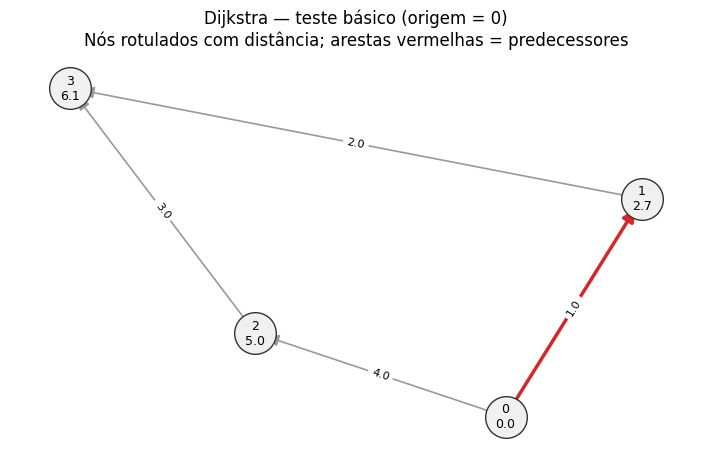

In [23]:
import matplotlib.pyplot as plt
import networkx as nx

# Constrói o grafo direcionado a partir do teste básico do Dijkstra
Gd = nx.DiGraph()
for u, viz in grafo_teste.items():
    for v, w in viz:
        Gd.add_edge(u, v, weight=w)

# Arestas da árvore de predecessores do Dijkstra
parent_edges_d = set()
for v, p in resultado.parent.items():
    if p is not None:
        parent_edges_d.add((p, v))

# Layout e desenho
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
pos = nx.spring_layout(Gd, seed=42)

nx.draw_networkx_nodes(Gd, pos, node_color="#f0f0f0", edgecolors="#333", node_size=900, ax=ax)
node_labels = {v: f"{v}\n{('∞' if resultado.dist[v] == inf else round(resultado.dist[v], 1))}" for v in Gd.nodes()}
nx.draw_networkx_labels(Gd, pos, labels=node_labels, font_size=9, ax=ax)

edge_colors = ["tab:red" if (u, v) in parent_edges_d else "#999" for u, v in Gd.edges()]
edge_widths = [2.5 if (u, v) in parent_edges_d else 1.2 for u, v in Gd.edges()]

nx.draw_networkx_edges(Gd, pos, edge_color=edge_colors, width=edge_widths, arrows=True, arrowsize=18, ax=ax)
edge_labels = {(u, v): Gd[u][v]["weight"] for u, v in Gd.edges()}
nx.draw_networkx_edge_labels(Gd, pos, edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title("Dijkstra — teste básico (origem = 0)\nNós rotulados com distância; arestas vermelhas = predecessores")
ax.set_axis_off()
plt.show()

### (a) Gerar grafos completos com pesos estritamente positivos

Vamos gerar grafos completos com número de vértices variando de 4 até N, atribuindo pesos aleatórios estritamente positivos (w > 0) para cada aresta. O grafo será representado por uma lista de adjacência (`Adj`).

In [5]:
def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0) -> Adj:
    """Gera um grafo completo dirigido com n vértices e pesos estritamente positivos."""
    adj: Adj = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                peso = random.uniform(peso_min, peso_max)
                adj[u].append((v, peso))
    return adj

# Exemplo de uso: gerar e exibir um grafo completo pequeno
N_exemplo = 5
grafo_completo = gerar_grafo_completo(N_exemplo)
print(f"Grafo completo com {N_exemplo} vértices:")
for u in grafo_completo:
    print(f"{u}: {[f'{v} (w={w:.2f})' for v, w in grafo_completo[u]]}")

Grafo completo com 5 vértices:
0: ['1 (w=6.16)', '2 (w=2.28)', '3 (w=6.87)', '4 (w=3.65)']
1: ['0 (w=8.88)', '2 (w=5.54)', '3 (w=8.27)', '4 (w=3.44)']
2: ['0 (w=9.46)', '1 (w=4.94)', '3 (w=2.30)', '4 (w=6.39)']
3: ['0 (w=2.79)', '1 (w=3.45)', '2 (w=2.30)', '4 (w=8.14)']
4: ['0 (w=8.66)', '1 (w=9.78)', '2 (w=5.92)', '3 (w=1.03)']


### (b) Armazenar cada grafo em uma estrutura de dados (lista de adjacência)

Para cada valor de n, vamos gerar e armazenar o grafo completo em uma lista de adjacência. Os grafos podem ser guardados em uma lista para uso posterior nos experimentos.

In [6]:
# Parâmetros do experimento
N_min = 4
N_max = 10  # Aumente para valores maiores conforme desejado (ex: 1000, 10000, etc.)

# Lista para armazenar os grafos completos gerados
grafos_completos = []

for n in range(N_min, N_max + 1):
    grafo = gerar_grafo_completo(n)
    grafos_completos.append(grafo)  # Armazena o grafo na lista

print(f"{len(grafos_completos)} grafos completos armazenados (de {N_min} a {N_max} vértices)")

7 grafos completos armazenados (de 4 a 10 vértices)


### Teste básico — visualização do grafo (Heurística Gulosa)

O grafo abaixo mostra as arestas com seus pesos. As arestas que compõem a árvore de predecessores encontrada pela heurística (a partir de 0) estão destacadas.

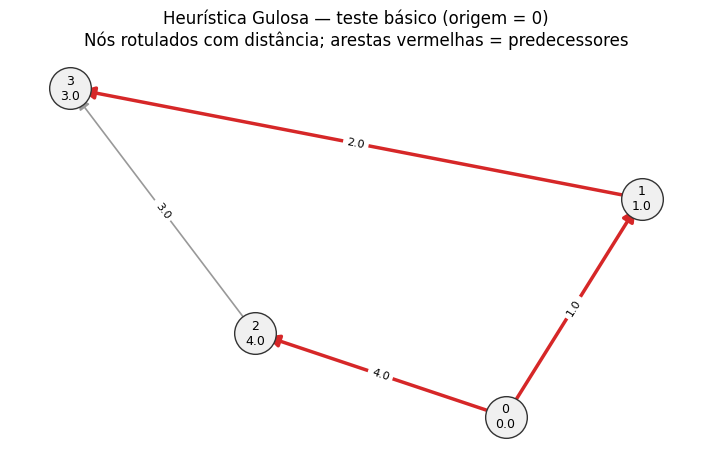

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

# Constrói o grafo direcionado a partir do teste básico da gulosa
G = nx.DiGraph()
for u, viz in grafo_teste_g.items():
    for v, w in viz:
        G.add_edge(u, v, weight=w)

# Conjunto de arestas da árvore de predecessores encontrada pela heurística
parent_edges = set()
for v, p in res_g.parent.items():
    if p is not None:
        parent_edges.add((p, v))

# Layout e desenho
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
pos = nx.spring_layout(G, seed=42)

# Desenha nós
nx.draw_networkx_nodes(G, pos, node_color="#f0f0f0", edgecolors="#333", node_size=900, ax=ax)

# Rótulos de nós com distâncias da heurística
node_labels = {v: f"{v}\n{('∞' if res_g.dist[v] == inf else round(res_g.dist[v], 1))}" for v in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, ax=ax)

# Cores para arestas: destaque as da árvore (vermelho), demais em cinza
edge_colors = ["tab:red" if (u, v) in parent_edges else "#999" for u, v in G.edges()]
edge_widths = [2.5 if (u, v) in parent_edges else 1.2 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, arrows=True, arrowsize=18, ax=ax)

# Rótulos de arestas com pesos
edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title("Heurística Gulosa — teste básico (origem = 0)\nNós rotulados com distância; arestas vermelhas = predecessores")
ax.set_axis_off()
plt.show()

### (c) Aplicar o algoritmo de Dijkstra em cada grafo gerado

Para cada grafo completo armazenado, vamos aplicar o algoritmo de Dijkstra considerando o vértice 0 como origem.

In [7]:
# Aplicar Dijkstra em cada grafo completo gerado, usando origem 0
resultados_dijkstra = []  # Lista para armazenar os resultados (distâncias, pais, comparações)

for idx, grafo in enumerate(grafos_completos):
    resultado = dijkstra_count(grafo, s=0)
    resultados_dijkstra.append(resultado)

print(f"Dijkstra aplicado em {len(resultados_dijkstra)} grafos completos (origem = 0)")

Dijkstra aplicado em 7 grafos completos (origem = 0)


### (d) Contar o número de comparações realizadas para cada grafo de entrada

Vamos extrair o número de comparações realizadas pelo Dijkstra em cada grafo e exibir uma tabela com o número de vértices e o número de comparações.

In [8]:
# Extrair número de vértices e comparações de cada execução
ns = list(range(N_min, N_max + 1))
comparacoes = [res.comparisons for res in resultados_dijkstra]

print("n_vértices\tcomparações")
for n, comp in zip(ns, comparacoes):
    print(f"{n}\t\t{comp}")

n_vértices	comparações
4		12
5		20
6		30
7		42
8		56
9		72
10		90


In [9]:
# Salvar tabela de Dijkstra em TXT
pasta_out = garantir_pasta_saida("resultados")
arquivo_dijkstra = os.path.join(pasta_out, f"dijkstra_comparacoes_{timestamp_sufixo()}.txt")
linhas_dijkstra = list(zip(ns, comparacoes))
salvar_tabela_txt("n\tcomparacoes_dijkstra", linhas_dijkstra, arquivo_dijkstra)

[OK] Tabela salva em: resultados\dijkstra_comparacoes_20251101-090429.txt


### (e) Plotar gráfico: número de vértices (n) vs número de comparações

Vamos plotar o gráfico solicitado, usando Matplotlib, com Eixo X = número de vértices (n) e Eixo Y = número de comparações.

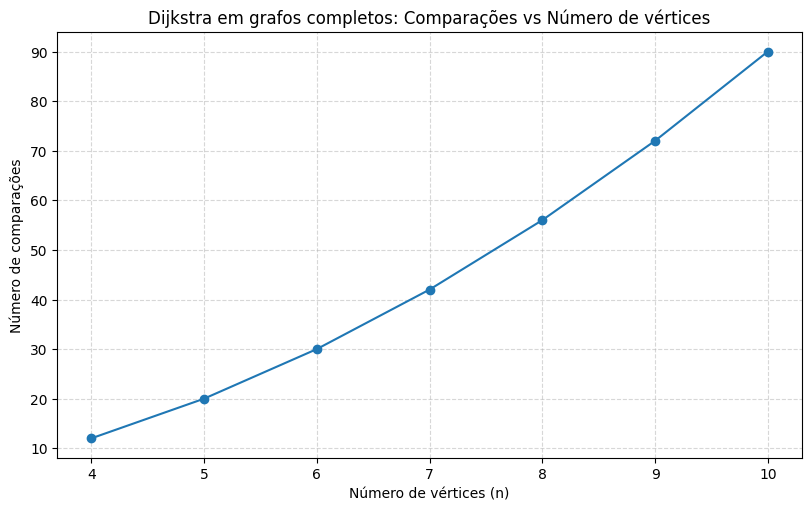

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5), constrained_layout=True)
plt.plot(ns, comparacoes, marker='o', color='tab:blue')
plt.xlabel('Número de vértices (n)')
plt.ylabel('Número de comparações')
plt.title('Dijkstra em grafos completos: Comparações vs Número de vértices')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### (f) Aplicar o algoritmo em duas instâncias grandes (10.000 e 1.000.000 vértices)

Nesta etapa vamos usar as instâncias fornecidas no Moodle (formato EWD):
- "D:\\OneDrive\\Pessoais\\Doutorado\\Cefet\\022025\\Teoria de Grafos\\10000.txt"
- "D:\\OneDrive\\Pessoais\\Doutorado\\Cefet\\022025\\Teoria de Grafos\\largeEWD - contains one million vertices and 15172126 edges.txt"

Origem fixa no vértice 0. Reportaremos o número de comparações e tempos de carga/execução. A execução da instância de 1.000.000 é protegida por flag para evitar travamentos acidentais.

In [11]:
from time import perf_counter
import os

caminho_10k = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt"
caminho_1m = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt"


def executar_instancia(caminho: str, origem: int = 0, nome: str | None = None):
    nome = nome or os.path.basename(caminho)
    if not os.path.exists(caminho):
        print(f"[AVISO] Arquivo não encontrado: {caminho}")
        return None
    print(f"\nCarregando {nome}...")
    t0 = perf_counter()
    adj = carregar_grafo_ewd(caminho)
    t1 = perf_counter()
    print(f"Grafo carregado: V={len(adj)} | tempo de carga: {t1 - t0:.2f}s")
    print("Executando Dijkstra (origem=0)...")
    t2 = perf_counter()
    res = dijkstra_count(adj, s=origem)
    t3 = perf_counter()
    print(f"Comparações: {res.comparisons:,} | tempo Dijkstra: {t3 - t2:.2f}s")
    return res

# Executa a instância de 10.000 vértices, se disponível
res_10k = executar_instancia(caminho_10k, origem=0, nome="Instância 10.000")

# Proteção para a instância de 1.000.000 (muito pesada). Altere para True se desejar executar.
RUN_1M = False
if RUN_1M:
    res_1m = executar_instancia(caminho_1m, origem=0, nome="Instância 1.000.000")


Carregando Instância 10.000...
Grafo carregado: V=10000 | tempo de carga: 0.29s
Executando Dijkstra (origem=0)...
Comparações: 123,462 | tempo Dijkstra: 0.10s
Grafo carregado: V=10000 | tempo de carga: 0.29s
Executando Dijkstra (origem=0)...
Comparações: 123,462 | tempo Dijkstra: 0.10s


In [12]:
# Salvar comparações das instâncias grandes de Dijkstra, se executadas
if 'res_10k' in globals() and res_10k is not None:
    pasta_out = garantir_pasta_saida('resultados')
    caminho = os.path.join(pasta_out, f"dijkstra_instancias_{timestamp_sufixo()}.txt")
    salvar_tabela_txt("instancia\tcomparacoes", [("10k", res_10k.comparisons)], caminho)

[OK] Tabela salva em: resultados\dijkstra_instancias_20251101-090434.txt


---
# PARTE 2 — HEURÍSTICA GULOSA
---

## Parte 2 - I. Implementação da Heurística Gulosa

Heurística escolhida: um único varrimento de relaxamento sobre todas as arestas (ordem fixa da lista de adjacência). É uma aproximação do caminho mínimo por origem única — não garante otimalidade, mas é simples, linear no número de arestas e adequada para comparação experimental. A contagem de comparações corresponde ao número de verificações da condição de relaxamento (dist[u] + w < dist[v]).

In [13]:
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from math import inf

# Reutiliza o tipo Adj definido anteriormente neste notebook

@dataclass
class GulosaResult:
    dist: Dict[int, float]
    parent: Dict[int, Optional[int]]
    comparacoes: int


def heuristica_gulosa(adj: Adj, s: int) -> GulosaResult:
    """
    Heurística gulosa: um único varrimento de relaxamento sobre todas as arestas.
    - dist[s] = 0, demais = inf
    - Para cada aresta (u, v, w) em ordem de adjacência, se dist[u] + w < dist[v], atualiza.
    - Contagem de comparações = número de checagens de relaxamento.
    """
    if s not in adj:
        raise ValueError(f"Vértice de origem {s} não pertence ao grafo.")

    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0

    comparacoes = 0
    for u in adj:
        for v, w in adj[u]:
            comparacoes += 1
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u

    return GulosaResult(dist=dist, parent=parent, comparacoes=comparacoes)

### Teste básico da heurística gulosa

In [14]:
grafo_teste_g: Adj = {
    0: [(1, 1.0), (2, 4.0)],
    1: [(3, 2.0)],
    2: [(3, 3.0)],
    3: []
}
res_g = heuristica_gulosa(grafo_teste_g, 0)
print("Distâncias pela heurística (origem=0):")
for v in sorted(res_g.dist.keys()):
    d = res_g.dist[v]
    print(f"  v={v}: dist={'∞' if d==inf else d}")
print(f"Comparações (heurística): {res_g.comparacoes}")

Distâncias pela heurística (origem=0):
  v=0: dist=0.0
  v=1: dist=1.0
  v=2: dist=4.0
  v=3: dist=3.0
Comparações (heurística): 4


### (a) Gerar grafos completos com pesos estritamente positivos

Vamos gerar grafos completos com número de vértices variando de 4 até N, atribuindo pesos aleatórios estritamente positivos (w > 0) para cada aresta. Reutilizaremos a função `gerar_grafo_completo(n)` já definida na Parte 1.

### (b) Armazenar cada grafo em uma estrutura de dados (lista de adjacência)

Para cada valor de n, vamos gerar e armazenar o grafo completo em uma lista de adjacência (`Adj`) para uso nos experimentos da heurística.

In [ ]:
# Exemplo (Parte 2 - (a)): gerar um grafo completo pequeno
N_exemplo_g2 = 5
ex_grafo_gulosa = gerar_grafo_completo(N_exemplo_g2)
print(f"Grafo completo (heurística) com {N_exemplo_g2} vértices:")
for u in ex_grafo_gulosa:
    print(f"{u}: {[f'{v} (w={w:.2f})' for v, w in ex_grafo_gulosa[u]]}")

In [15]:
LIMITE_N = 1_000_000
N_min_gulosa = N_min if 'N_min' in globals() else 4
N_max_gulosa = min((N_max if 'N_max' in globals() else 10), LIMITE_N)

ns_gulosa = list(range(N_min_gulosa, N_max_gulosa + 1))
grafos_gulosa: List[Adj] = []
for n in ns_gulosa:
    grafos_gulosa.append(gerar_grafo_completo(n))
print(f"{len(grafos_gulosa)} grafos completos armazenados para a heurística (de {N_min_gulosa} a {N_max_gulosa} vértices)")

7 grafos completos armazenados para a heurística (de 4 a 10 vértices)


### (c)–(d) Aplicar a heurística e contar comparações

In [16]:
resultados_gulosa: List[GulosaResult] = []
comparacoes_gulosa: List[int] = []
for g in grafos_gulosa:
    r = heuristica_gulosa(g, 0)
    resultados_gulosa.append(r)
    comparacoes_gulosa.append(r.comparacoes)

print("n_vértices\tcomparações (gulosa)")
for n, c in zip(ns_gulosa, comparacoes_gulosa):
    print(f"{n}\t\t{c}")

n_vértices	comparações (gulosa)
4		12
5		20
6		30
7		42
8		56
9		72
10		90


In [17]:
# Salvar tabela da heurística gulosa em TXT
pasta_out = garantir_pasta_saida("resultados")
arquivo_gulosa = os.path.join(pasta_out, f"gulosa_comparacoes_{timestamp_sufixo()}.txt")
linhas_gulosa = list(zip(ns_gulosa, comparacoes_gulosa))
salvar_tabela_txt("n\tcomparacoes_gulosa", linhas_gulosa, arquivo_gulosa)

[OK] Tabela salva em: resultados\gulosa_comparacoes_20251101-090435.txt


### (e) Plotar gráfico: n (vértices) vs comparações (heurística)  — N ≤ 1.000.000

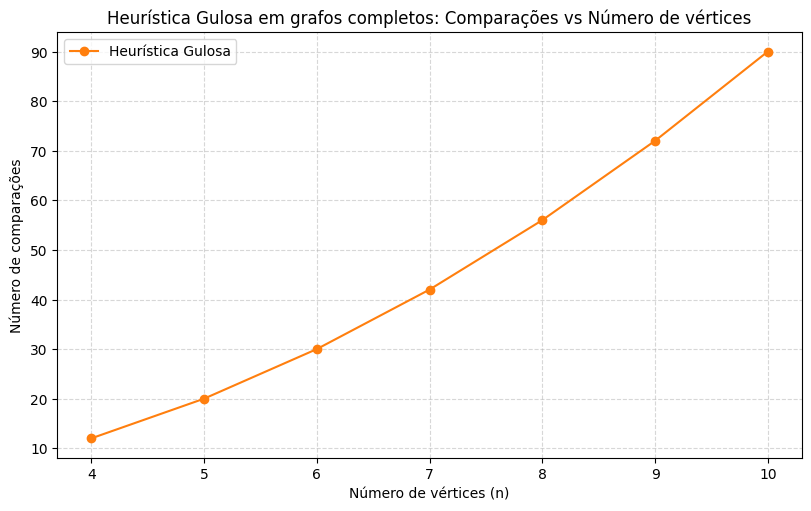

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5), constrained_layout=True)
plt.plot(ns_gulosa, comparacoes_gulosa, marker='o', color='tab:orange', label='Heurística Gulosa')
plt.xlabel('Número de vértices (n)')
plt.ylabel('Número de comparações')
plt.title('Heurística Gulosa em grafos completos: Comparações vs Número de vértices')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### (f) Instâncias do Moodle — 10.000 e 1.000.000 de vértices (origem = 0) — Heurística Gulosa

In [19]:
from time import perf_counter
import os

caminho_10k = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt"
caminho_1m = r"D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt"


def executar_instancia_gulosa(caminho: str, origem: int = 0, nome: str | None = None):
    nome = nome or os.path.basename(caminho)
    if not os.path.exists(caminho):
        print(f"[AVISO] Arquivo não encontrado: {caminho}")
        return None
    print(f"\nCarregando {nome}...")
    t0 = perf_counter()
    adj = carregar_grafo_ewd(caminho)
    t1 = perf_counter()
    print(f"Grafo carregado: V={len(adj)} | tempo de carga: {t1 - t0:.2f}s")
    print("Executando Heurística Gulosa (origem=0)...")
    t2 = perf_counter()
    res = heuristica_gulosa(adj, s=origem)
    t3 = perf_counter()
    print(f"Comparações (gulosa): {res.comparacoes:,} | tempo heurística: {t3 - t2:.2f}s")
    return res

# Executa a instância de 10.000 vértices, se disponível
res_g_10k = executar_instancia_gulosa(caminho_10k, origem=0, nome="Instância 10.000 — Gulosa")

# Proteção para a instância de 1.000.000 (muito pesada). Altere para True se desejar executar.
RUN_1M_GULOSA = False
if RUN_1M_GULOSA:
    res_g_1m = executar_instancia_gulosa(caminho_1m, origem=0, nome="Instância 1.000.000 — Gulosa")


Carregando Instância 10.000 — Gulosa...
Grafo carregado: V=10000 | tempo de carga: 0.20s
Executando Heurística Gulosa (origem=0)...
Comparações (gulosa): 123,462 | tempo heurística: 0.08s
Comparações (gulosa): 123,462 | tempo heurística: 0.08s


In [20]:
# Salvar comparações das instâncias grandes (heurística), se executadas
if 'res_g_10k' in globals() and res_g_10k is not None:
    pasta_out = garantir_pasta_saida('resultados')
    caminho = os.path.join(pasta_out, f"gulosa_instancias_{timestamp_sufixo()}.txt")
    salvar_tabela_txt("instancia\tcomparacoes_gulosa", [("10k", res_g_10k.comparacoes)], caminho)

[OK] Tabela salva em: resultados\gulosa_instancias_20251101-090435.txt
